# Exercise 8 Bootstraping

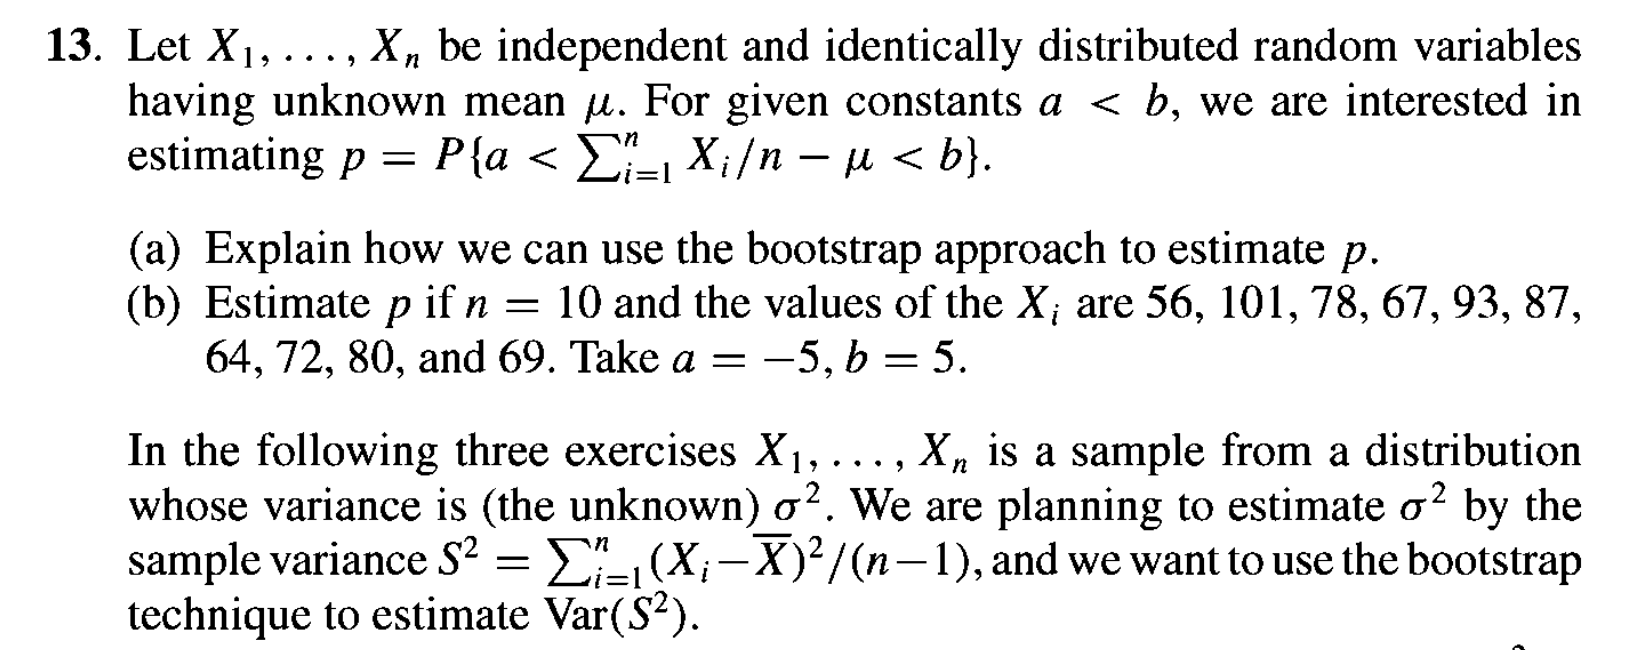

In [13]:
# part 1 sole exercise 13 in chapter 8 of ross (p152)
# (a) Since we do not know the true distribution, but only have a a range of points,  we can use the the provoided 
# points with a bootstrap tecnique to simulate a larger true distribution. Specifically we will need the 
# bootstraping to estimate the mean.

# (b)
import numpy as np
np.random.seed(42)
X = [56,101,78,67,93,87,64,72,80,69]
n = 10
a = -5
b = 5

M_samples = 100
x_bar = np.mean(X)

bootstrap_means = []

for i in range(M_samples):
    sample = np.random.choice(X, size=n, replace=True)
    bootstrap_means.append(np.mean(sample))

bootstrap_means = np.array(bootstrap_means)

# Bootstrap approximation of X_bar - mu
diffs = bootstrap_means - x_bar

p_hat = np.mean((a < diffs) & (diffs < b))

print("sample mean:", x_bar)
print("estimated p:", p_hat)



sample mean: 76.7
estimated p: 0.74


## part 2 

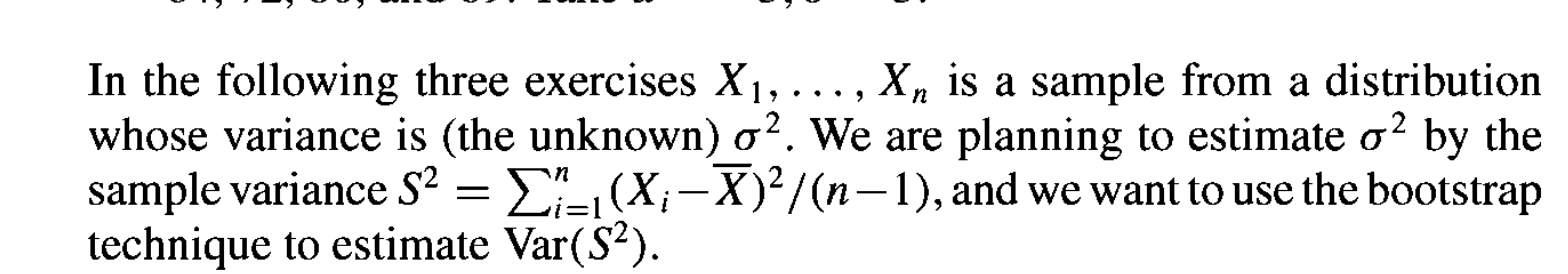
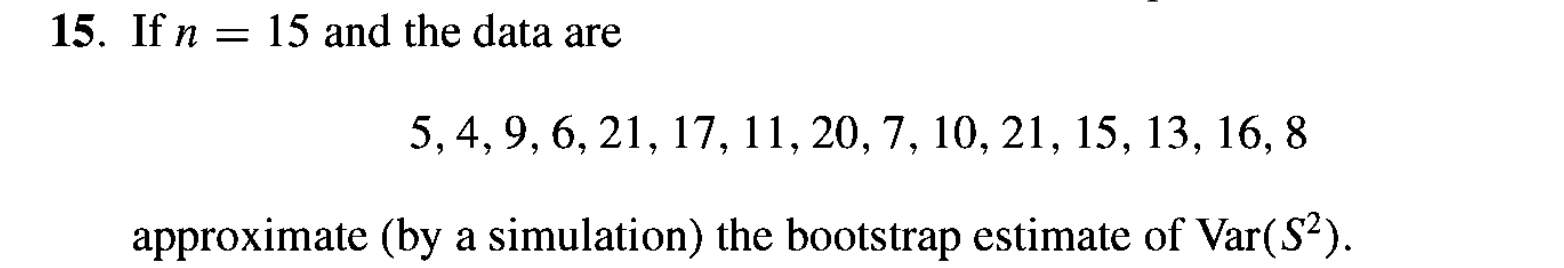

In [15]:
X = np.array([5,4,9,6,21,17,11,20,7,10,21,15,13,16,8])
n = len(X)

B = 10000

bootstrap_variances = []

for _ in range(B):
    sample = np.random.choice(X, size=n, replace=True)

    # ddof=1 gives denominator n-1
    S2_star = np.var(sample, ddof=1)

    bootstrap_variances.append(S2_star)

bootstrap_variances = np.array(bootstrap_variances)

var_S2_bootstrap = np.var(bootstrap_variances, ddof=1)

print("Bootstrap estimate of Var(S^2):", var_S2_bootstrap)

Bootstrap estimate of Var(S^2): 58.44314831485961


## Part 3 

In [25]:
np.random.seed(42)
def estimate_sample_with_bootstrap(X, k =10_000):
    n = len(X)
    sample_median = np.median(X)
    sample_mean = np.mean(X)
    boot_medians = []
    boot_means = []
    for _ in range(k):
        sample = np.random.choice(X, size=n, replace=True)
        boot_medians.append(np.median(np.array(sample)))
        boot_means.append(np.mean(np.array(sample)))

        # ddof=1 gives denominator n-1
    theta_bar_med = np.mean(boot_medians)
    theta_bar_mean = np.mean(boot_means)

    Var_boot_median = np.sum((boot_medians-theta_bar_med)**2)/(k-1)
    Var_boot_mean = np.sum((boot_means-theta_bar_mean)**2)/(k-1)


    return sample_median, Var_boot_median, sample_mean, Var_boot_mean


X = 1 + np.random.pareto(1.05, size=200)


sample_median, Var_boot_median, sample_mean, Var_boot_mean = estimate_sample_with_bootstrap(X, k=100)

print(f"Sample mean = {sample_mean} | bootstrap variance of mean = {Var_boot_mean} \nSample median = {sample_median} | bootstrap variance of median = {Var_boot_median} ")

Sample mean = 4.225954964437149 | bootstrap variance of mean = 0.27330199248714815 
Sample median = 1.914960542162116 | bootstrap variance of median = 0.02977162605075171 


In [ ]:
#The bootstrap variance of the sample mean is much larger than that of the sample median.
#  This is expected because the Pareto distribution with k=1.05 is very heavy-tailed.
#  A few very large observations can strongly affect the mean, while the median is more 
# robust. Therefore, the median is the more precise estimator in this simulation.